# Phishing Website Detection using Machine Learning

## Notebook 07: Model Evaluation and Comparison

### Objective

The objective of this notebook is to perform a detailed evaluation of the best baseline and tuned machine learning models. Their performance is compared using standard classification metrics and confusion matrices to determine the final model for phishing website detection.

---


## 1. Import Libraries

Import the required libraries for hyperparameter tuning, model evaluation, and saving the optimized models.

In [19]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

## 2. Load the Engineered Dataset

Load the engineered phishing website dataset created in the previous notebook (notebook 4).

In [20]:
df = pd.read_csv("../dataset/engineered_phishing_dataset.csv")


## 3. Split Dataset

In [21]:
X = df.drop("phishing", axis=1)
y = df["phishing"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## 4. Load the Best Models

Load the best baseline model and the best tuned model for evaluation.

In [22]:
baseline_model = joblib.load("../models/baseline/CatBoost.pkl")

tuned_model = joblib.load("../models/tuned/LightGBM.pkl")

## 5. Create Helper Functions

Create reusable helper functions to evaluate machine learning models and visualize their classification performance.

### 5.1 Evaluate Model

Create a helper function to evaluate the classification performance of a machine learning model.

In [23]:
def evaluate_model(model, X_test, y_test):
    """
    Evaluate a machine learning model.
    """

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    return y_pred

### 5.2 Plot Confusion Matrix

Create a helper function to visualize the classification performance using a confusion matrix.

In [24]:
def plot_confusion_matrix(y_test, y_pred):
    """
    Plot the confusion matrix.
    """

    cm = confusion_matrix(y_test, y_pred)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Legitimate", "Phishing"]
    ).plot(cmap="Blues")

    plt.title("Confusion Matrix")
    plt.show()

## 6. Evaluate the Best Baseline Model

**Question:** How well does the best baseline model classify phishing and legitimate websites?

Evaluate the best baseline model using standard classification metrics, a confusion matrix, and a classification report.

### 6.1 Performance Metrics

Evaluate the classification performance of the best baseline model.

In [36]:
print("Best Baseline Model: CatBoost\n")

baseline_predictions = evaluate_model(
    baseline_model,
    X_test,
    y_test
)

Best Baseline Model: CatBoost

Accuracy : 0.8305
Precision: 0.8871
Recall   : 0.8842
F1 Score : 0.8856


### 6.2 Confusion Matrix

Visualize the classification performance of the best baseline model using a confusion matrix.

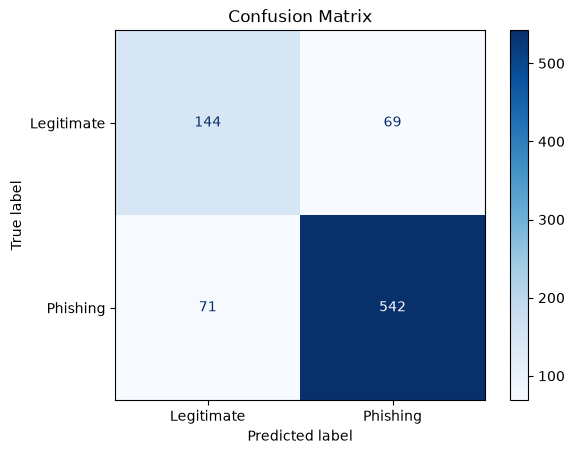

In [26]:
plot_confusion_matrix(
    y_test,
    baseline_predictions
)

### 6.3 Classification Report

Generate a detailed classification report for the best baseline model.

In [39]:
print(
    classification_report(
        y_test,
        baseline_predictions,
        target_names=["Legitimate", "Phishing"]
    )
)

              precision    recall  f1-score   support

  Legitimate       0.67      0.68      0.67       213
    Phishing       0.89      0.88      0.89       613

    accuracy                           0.83       826
   macro avg       0.78      0.78      0.78       826
weighted avg       0.83      0.83      0.83       826



### Interpretation

- The baseline CatBoost model achieved an overall **Accuracy of 83%** and a **weighted F1 Score of 0.83**.
- The model classified **phishing websites** more effectively (**F1 Score = 0.89**) than **legitimate websites** (**F1 Score = 0.67**).
- This difference is expected because the dataset contains considerably more phishing samples than legitimate samples.
- Overall, the baseline model demonstrated strong performance while maintaining a good balance between Precision and Recall.

---

## 7. Evaluate the Best Tuned Model

**Question:** How well does the best tuned model classify phishing and legitimate websites?

Evaluate the best tuned model using standard classification metrics, a confusion matrix, and a classification report.

### 7.1 Performance Metrics

Evaluate the classification performance of the best tuned model.

In [35]:
print("Best Tuned Model: LightGBM\n")

tuned_predictions = evaluate_model(
    tuned_model,
    X_test,
    y_test
)

Best Tuned Model: LightGBM

Accuracy : 0.8354
Precision: 0.8995
Recall   : 0.8760
F1 Score : 0.8876


### 7.2 Confusion Matrix

Visualize the classification performance of the best tuned model using a confusion matrix.

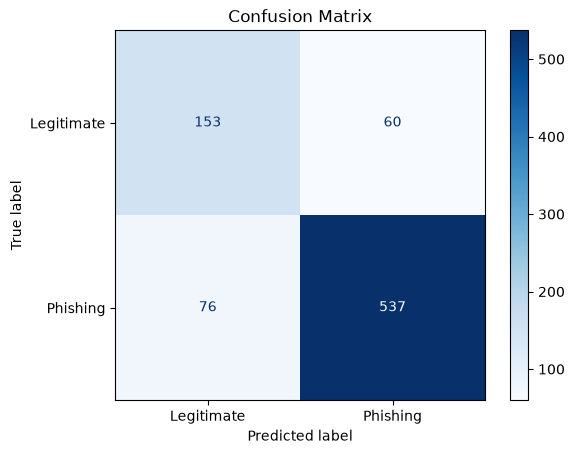

In [37]:
plot_confusion_matrix(
    y_test,
    tuned_predictions
)

### 7.3 Classification Report

Generate a detailed classification report for the best tuned model.

In [38]:
print(
    classification_report(
        y_test,
        tuned_predictions,
        target_names=["Legitimate", "Phishing"]
    )
)

              precision    recall  f1-score   support

  Legitimate       0.67      0.72      0.69       213
    Phishing       0.90      0.88      0.89       613

    accuracy                           0.84       826
   macro avg       0.78      0.80      0.79       826
weighted avg       0.84      0.84      0.84       826



### Interpretation

- The tuned LightGBM model achieved an overall **Accuracy of 84%** and a **weighted F1 Score of 0.84**.
- The model classified **phishing websites** very effectively (**F1 Score = 0.89**) while improving the classification of **legitimate websites** (**F1 Score = 0.69**) compared to the baseline model.
- The higher weighted F1 Score indicates that hyperparameter tuning resulted in a small but measurable improvement in overall classification performance.
- Overall, the tuned LightGBM model provided the best performance and was selected as the final model for phishing website detection.

---

## 8. Compare the Models

**Question:** Which model performs better for phishing website detection?

Compare the best baseline model and the best tuned model using the evaluation metrics obtained from the testing dataset.

### 8.1 Performance Comparison

Create a comparison table to evaluate the baseline and tuned models using the standard classification metrics.

In [40]:
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Baseline (CatBoost)": [
        0.8305,
        0.8871,
        0.8842,
        0.8856
    ],
    "Tuned (LightGBM)": [
        0.8354,
        0.8995,
        0.8760,
        0.8876
    ]
})

comparison_df

,Metric,Baseline (CatBoost),Tuned (LightGBM)
0,Accuracy,0.8305,0.8354
1,Precision,0.8871,0.8995
2,Recall,0.8842,0.8760
3,F1 Score,0.8856,0.8876


### Interpretation

- The tuned **LightGBM** model achieved higher **Accuracy**, **Precision**, and **F1 Score** than the baseline **CatBoost** model.
- Although the baseline CatBoost model achieved a slightly higher **Recall**, the tuned LightGBM model produced the highest **F1 Score**, providing a better balance between Precision and Recall.
- Since the phishing website dataset is imbalanced, **F1 Score** is considered the primary evaluation metric.
- Based on the overall performance, the tuned **LightGBM** model was selected as the final model for phishing website detection.

---

## 9. Key Findings

- The best baseline (**CatBoost**) and best tuned (**LightGBM**) models were evaluated using the testing dataset.
- Both models achieved strong classification performance for phishing website detection.
- The tuned **LightGBM** model achieved higher **Accuracy**, **Precision**, and **F1 Score** than the baseline CatBoost model.
- Although CatBoost achieved a slightly higher **Recall**, LightGBM produced the highest **F1 Score**, making it the better overall model for the imbalanced dataset.
- Based on the evaluation results, **LightGBM** was selected as the final model for phishing website detection.

## 10. Conclusion

- This notebook evaluated and compared the best baseline and tuned machine learning models using standard classification metrics. 
- The comparison showed that the tuned **LightGBM** model achieved the best overall performance, particularly in terms of **F1 Score**, which is the primary evaluation metric for this imbalanced dataset. 
- Therefore, the tuned LightGBM model was selected as the final model for phishing website detection.